In [15]:
import pandas as pd
import numpy as np
import glob #lets you find files matching a pattern (we willl see how it works).
import itertools #tools for looping 
from pathlib import Path # Handle filesystem paths (Path("dir") / "file.fits" ). It is optional but make things easier to read.
import numpy as np #numerical and data handler
import pandas as pd #numerical and data handler. This is how we handle the DataFrames.
from astropy import units as u #astronomy standard library (attach physical units to number)
from astropy.coordinates import SkyCoord #astronomy standard library (stores celestial coordinates)
#from gammapy.stats import WStatCountsStatistic #implements the W-statistic (Li & Ma–style). Common in Cherenkov telescope work.
#from magicctapipe.io import get_dl2_mean, get_stereo_events_old #reads DL2 files and computes mean values. The other one reads stereo event files.
#from magicctapipe.utils import calculate_off_coordinates #used to compute OFF regions for background estimation.
from astropy.table import Table, QTable
#import pyirf
import operator
from matplotlib import pyplot as plt #standard Python plotting library

In [2]:
!pwd


/Users/macbook/Divtel


In [3]:
f = open("/Users/macbook/Downloads/GRB_and_runs.txt")
print(f.read())

﻿230812B	3 
230512A 	5 
200711A	1 
200826	0 
210217	0 
210511B	4
210704A	0
210707	0
210803 	0
210910	0
220302A	3
220311A	6
220521	5
220527A	0
220603	1	
221221	0
230328B	3
230414B	3
230723B	9
230724	0
230818	8
231110	10
231111A	6
231115A	16
231118	2
231215A	10
231216A	6
240204A	6
240502A	4
240615A	1
240805B	12
240809A	4
240825A	11
240929	6
240905E	10
250129A	4
250625A	4



In [5]:
df = pd.read_csv("/Users/macbook/Downloads/GRB_and_runs.txt")

In [7]:
df = pd.read_csv(
    "/Users/macbook/Downloads/GRB_and_runs.txt",
    sep=r"\s+",   # split on any whitespace
    header=None,  # no header in the file
    names=["GRB", "Runs"]  # assign column names
)

print(df.head())

       GRB  Runs
0  230812B     3
1  230512A     5
2  200711A     1
3   200826     0
4   210217     0


In [17]:
df

,GRB,Runs
0,230812B,3
1,230512A,5
2,200711A,1
3,200826,0
4,210217,0
5,210511B,4
6,210704A,0
7,210707,0
8,210803,0
9,210910,0


In [41]:
print(df[df['Runs']>5])

        GRB  Runs
11  220311A     6
18  230723B     9
20   230818     8
21   231110    10
22  231111A     6
23  231115A    16
25  231215A    10
26  231216A     6
27  240204A     6
30  240805B    12
32  240825A    11
33   240929     6
34  240905E    10


In [22]:
np.arange(0,10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

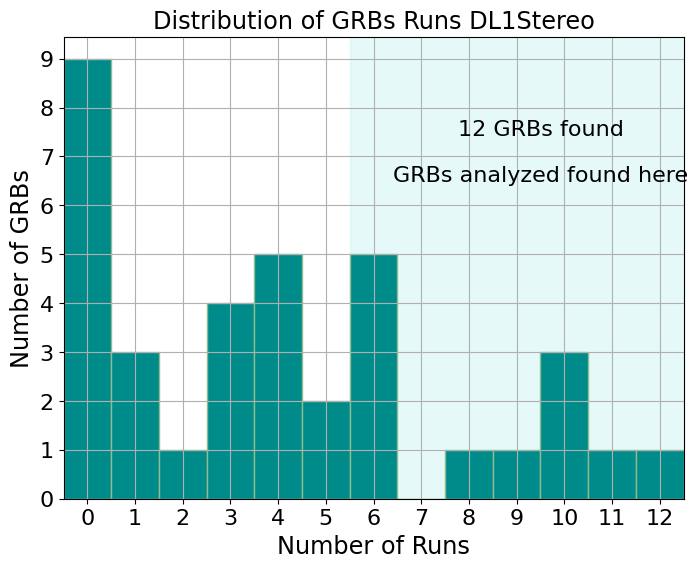

In [114]:
#x, bins=None, *, range=None, density=False, weights=None, cumulative=False, bottom=None, histtype='bar', align='mid', orientation='vertical', rwidth=None, log=False,
#color=None, label=None, stacked=False, data=None, **kwargs)
#counts, bins = np.histogram(df["Runs"], bins=np.arange(0,10))
plt.figure(figsize=(8,6))
plt.axvspan(6-0.5, 12.6, color='paleturquoise', alpha=0.3) 
plt.grid(True)
plt.title("Distribution of GRBs Runs DL1Stereo", fontsize='xx-large')
plt.hist(df["Runs"],bins=np.arange(-0.5, 12.500001, 1), color='darkcyan', alpha=1, edgecolor='darkseagreen')
plt.xlabel("Number of Runs", fontsize='xx-large')
plt.ylabel("Number of GRBs", fontsize='xx-large')

plt.tick_params(axis='both', which='major', labelsize=16)
plt.xlim(-0.5, 12.5)
# Force x-axis ticks at every integer
plt.text(
    9.5,                       # x-position (center of turquoise region)
    plt.ylim()[1] * 0.8,       # y-position (80% of plot height)
    "12 GRBs found",
    fontsize=16,
    color="black",
    ha="center", va="center",  # center alignment
  
)
plt.text(
    9.5,                       # x-position (center of turquoise region)
    plt.ylim()[1] * 0.7,       # y-position (80% of plot height)
    "GRBs analyzed found here",
    fontsize=16,
    color="black",
    ha="center", va="center",  # center alignment
  
)
plt.xticks(np.arange(0, 13, 1))  
plt.yticks(np.arange(0, 10, 1))
plt.show()
